In [ ]:
# import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
# load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [ ]:
# Normalizing images
x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0

In [ ]:
# Label conversion
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [ ]:
# CNN model

def build_model():
  model = keras.Sequential([
      layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = (32, 32, 3)),
      layers.MaxPooling2D((2,2)),

      layers.Conv2D(64, (3,3), activation='relu', padding = 'same'),
      layers.MaxPooling2D((2,2)),
      layers.Dropout(0.2),
      layers.Conv2D(128, (3,3), activation = 'relu', padding = 'same'),
      layers.MaxPooling2D((2,2)),

      # layers.Conv2D(256, (3,3), activation = 'relu', padding = 'same'),
      # layers.MaxPooling2D((2,2)),

      # Flatten
      layers.Flatten(),
      layers.Dense(128, activation = 'relu'),
      # layers.Dense(64, activation = 'relu'),
      layers.Dense(10, activation = 'softmax')

  ])

  return model

In [ ]:
model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

# Define the optimizer with custom parameters (e.g., learning rate and momentum)
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.7)


In [ ]:
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [ ]:
# train model
history = model.fit(
    x_train, y_train,
    batch_size = 128,
    epochs = 15,
    validation_split = 0.2,
    verbose = 1,
    shuffle = False
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.3911 - loss: 1.6706 - val_accuracy: 0.5180 - val_loss: 1.3513
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5639 - loss: 1.2300 - val_accuracy: 0.6051 - val_loss: 1.1151
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6321 - loss: 1.0453 - val_accuracy: 0.6534 - val_loss: 0.9870
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6768 - loss: 0.9284 - val_accuracy: 0.6845 - val_loss: 0.9231
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7066 - loss: 0.8445 - val_accuracy: 0.6906 - val_loss: 0.9139
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7298 - loss: 0.7788 - val_accuracy: 0.7122 - val_loss: 0.8483
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7489 - loss: 0.7190 - val_accuracy: 0.7178 - val_loss: 0.8312
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7650 - loss: 0.6703 - val_accuracy: 

In [ ]:
# model evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 1)
print('Test Loss: ', test_loss)
print('Test Accuracy: ', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7141 - loss: 1.0025
Test Loss:  1.0025018453598022
Test Accuracy:  0.7141000032424927


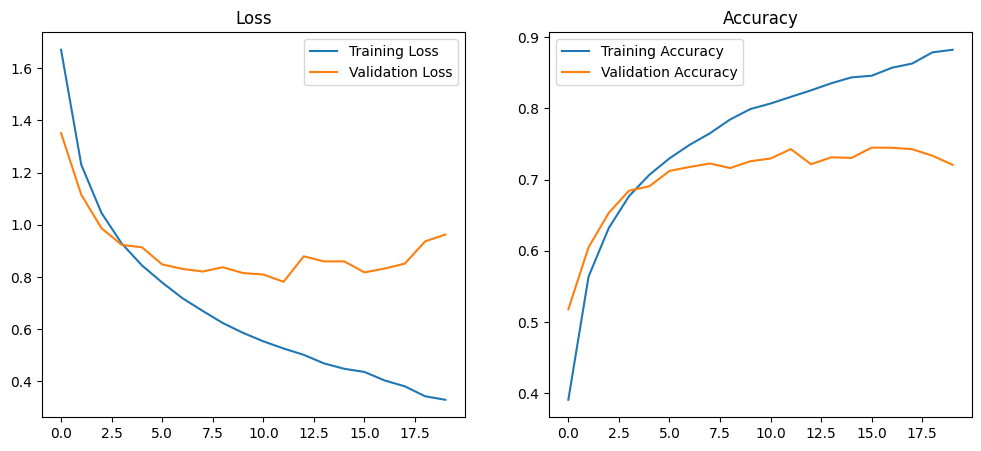

In [ ]:
# Accuracy and Loss plot
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.legend()
plt.title("Loss")

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label = "Training Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.show()

In [ ]:
# Feature extractor

layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]

model.build(input_shape=(None, 32, 32, 3))
feature_model = keras.Model(inputs = model.inputs, outputs = layer_outputs)

In [ ]:
# pick one image
img = x_test[1]
img = np.expand_dims(img, axis = 0)


In [ ]:
# get feature maps
feature_maps = feature_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step


Layer: 1


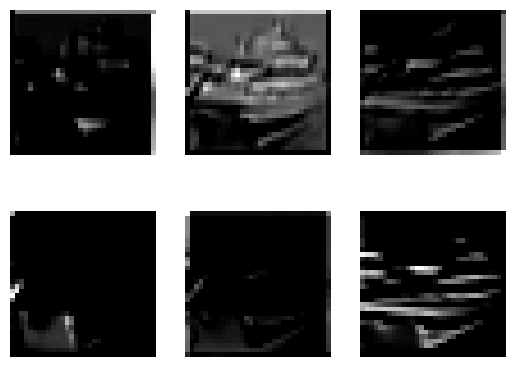

Layer: 2


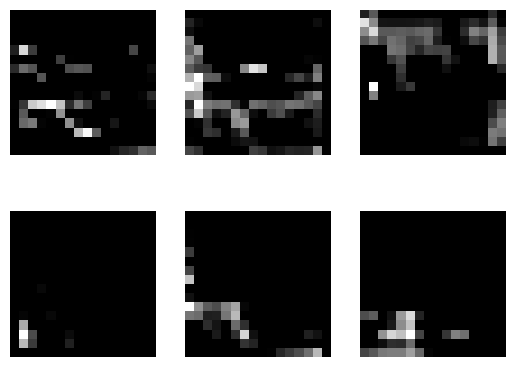

Layer: 3


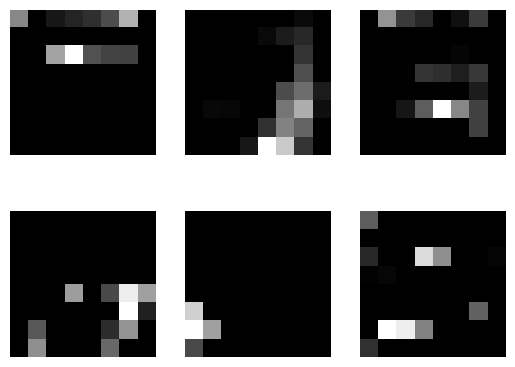

In [ ]:
# Plot feature maps
for i, feature_map in enumerate(feature_maps):
  print(f"Layer: {i+1}")

  # show first 6 feature maps
  for j in range(6):
    plt.subplot(2, 3, j+1)
    plt.imshow(feature_map[0, :, :, j], cmap = 'gray')
    plt.axis('off')

  plt.show()
